# NBA Game Predictor: Project Tour
Run All to revisit the whole project: NBA data, rolling features, Elo, training, evaluation, tuning, saved models, and upcoming predictions. Choose Python 3.12 or the .venv kernel.

The early sections reuse cached data; the final section contacts NBA.com. Outputs go to `reports/demo/` and the demo model is separate from production. This predicts home-team wins from team statistics: injuries, lineups, roster changes, and live odds are not included.

In [1]:
import sys
from pathlib import Path
from datetime import date
from importlib.metadata import version
from time import perf_counter
started = perf_counter()
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "modeling.py").exists()), None)
assert ROOT is not None, "Open this notebook inside the NBA project."
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
print("Python:", sys.executable, flush=True)
print("Project:", ROOT, flush=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from dataclasses import asdict
from data import load_game_logs
from modeling import train_model, load_or_build_model_frames, save_training_result, load_training_result
from prediction import predict_matchup
from production import load_production_config, run_production_predictions, american_odds_to_implied_probability
from evaluation import evaluate_probabilities, walk_forward_cv_scores
from features import select_feature_names
from tuning import tune_rolling_settings, tune_elo_settings, tune_model_grid
from nba_api.stats.static import players, teams

REPORTS = ROOT / "reports" / "demo"
REPORTS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 14)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
packages = ["nba_api", "pandas", "scikit-learn", "joblib", "ipykernel", "matplotlib"]
display(pd.DataFrame({"package": packages, "version": [version(p) for p in packages]}))
print(f"Imports ready in {perf_counter() - started:.1f}s.")

Python: C:\Users\ryanv\AppData\Local\Programs\Python\Python312\python.exe


Project: C:\Users\ryanv\OneDrive\Desktop\projects\relevant_projects\nba


,package,version
0,nba_api,1.11.4
1,pandas,3.0.5
2,scikit-learn,1.9.0
3,joblib,1.6.0
4,ipykernel,7.3.0
5,matplotlib,3.11.1


Imports ready in 12.4s.


## 1. Settings and code map
Production reads `production_config.txt`. The demo settings below are independent and use fixed historical seasons for repeatability. Edit HOME/AWAY to try another matchup.

| Module | Role |
|---|---|
| data.py | Download/cache NBA logs |
| features.py / elo.py | Rolling stats, interactions, ratings |
| modeling.py / evaluation.py | Training, persistence, scoring |
| tuning.py | Rolling, Elo, and combined grid searches |
| prediction.py / production.py | Matchup probabilities, schedules, tables |
| main.py / inspection.py | Terminal commands and stage exports |

In [2]:
production_config = load_production_config()
SEASONS = ["2023-24", "2024-25", "2025-26"]
SEASON_TYPES = ["Regular Season", "Playoffs"]
HOME, AWAY = "BOS", "NYK"
RUN_LIVE = True
RUN_SMALL_TUNING = True
settings = dict(
    seasons=SEASONS, season_types=SEASON_TYPES,
    rolling_window=10, min_periods=1, feature_set="deltas", feature_mode="lean",
    rolling_history="same-season", use_prior_season_features=False, prior_decay_games=30,
    use_elo=True, elo_k=15, elo_playoff_k=15, elo_home_advantage=65, elo_carryover=0.65,
)
display(pd.Series(asdict(production_config), name="Production settings").to_frame())
print("Demo seasons:", ", ".join(SEASONS))

,Production settings
seasons,"[2023-24, 2024-25, 2025-26]"
season_types,"[Regular Season, Playoffs]"
rolling_window,10
min_periods,1
rolling_history,same-season
use_prior_season_features,False
prior_decay_games,30
feature_set,deltas
feature_mode,lean
use_elo,True


Demo seasons: 2023-24, 2024-25, 2025-26


## 2. API exploration and cached games
The original demo explored static players/teams and game DataFrames. Static lookups below require no network. Logs reuse `data/raw/`; missing seasons are downloaded. Pass `refresh=True` deliberately when you want fresh logs.

Each game normally has two rows, one per team. Check the last-game dates to see how current the local data is.

In [3]:
print(f"Players in installed lookup: {len(players.get_players()):,}")
print(f"Active players in lookup: {len(players.get_active_players()):,}")
display(pd.DataFrame(teams.get_teams())[["abbreviation", "full_name", "city", "year_founded"]].head(10))
print("Loading cached logs...", flush=True)
logs = load_game_logs(SEASONS, season_types=SEASON_TYPES)
logs["GAME_DATE"] = pd.to_datetime(logs["GAME_DATE"])
display(logs.groupby(["SEASON_ID", "SEASON_TYPE"]).agg(
    team_rows=("GAME_ID", "size"), games=("GAME_ID", "nunique"),
    first_game=("GAME_DATE", "min"), last_game=("GAME_DATE", "max")).reset_index())
display(logs[["GAME_DATE", "TEAM_ABBREVIATION", "MATCHUP", "WL", "PTS", "PLUS_MINUS"]].tail(10))
display(logs.groupby("GAME_ID").size().value_counts().rename_axis("Rows per game").to_frame("Games"))

Players in installed lookup: 5,103
Active players in lookup: 530


,abbreviation,full_name,city,year_founded
0,ATL,Atlanta Hawks,Atlanta,1949
1,BOS,Boston Celtics,Boston,1946
2,CLE,Cleveland Cavaliers,Cleveland,1970
3,NOP,New Orleans Pelicans,New Orleans,2002
4,CHI,Chicago Bulls,Chicago,1966
5,DAL,Dallas Mavericks,Dallas,1980
6,DEN,Denver Nuggets,Denver,1976
7,GSW,Golden State Warriors,San Francisco,1946
8,HOU,Houston Rockets,Houston,1967
9,LAC,Los Angeles Clippers,Los Angeles,1970


Loading cached logs...


,SEASON_ID,SEASON_TYPE,team_rows,games,first_game,last_game
0,22023,Regular Season,2460,1230,2023-10-24,2024-04-14
1,22024,Regular Season,2460,1230,2024-10-22,2025-04-13
2,22025,Regular Season,2460,1230,2025-10-21,2026-04-12
3,42023,Playoffs,164,82,2024-04-20,2024-06-17
4,42024,Playoffs,168,84,2025-04-19,2025-06-22
5,42025,Playoffs,170,85,2026-04-18,2026-06-13


,GAME_DATE,TEAM_ABBREVIATION,MATCHUP,WL,PTS,PLUS_MINUS
7872,2026-06-03,NYK,NYK @ SAS,W,105,10
7873,2026-06-03,SAS,SAS vs. NYK,L,95,-10
7874,2026-06-05,NYK,NYK @ SAS,W,105,1
7875,2026-06-05,SAS,SAS vs. NYK,L,104,-1
7876,2026-06-08,SAS,SAS @ NYK,W,115,4
7877,2026-06-08,NYK,NYK vs. SAS,L,111,-4
7878,2026-06-10,SAS,SAS @ NYK,L,106,-1
7879,2026-06-10,NYK,NYK vs. SAS,W,107,1
7880,2026-06-13,SAS,SAS vs. NYK,L,90,-4
7881,2026-06-13,NYK,NYK @ SAS,W,94,4


,Games
Rows per game,
2,3941


## 3. Rolling features, matchups, and Elo
Rolling averages shift results by one game, preventing the current game's result from entering its own features. Rest days, box scores, recent win rate, and home-minus-away differences become inputs.

Elo adds team strength and recent rating changes. Playoff K controls playoff updates; carryover controls how much rating survives between seasons. `deltas` uses differences; `full` includes both teams and differences. Modes `base`, `lean`, and `full` select interaction subsets.

Building/loading features and Elo...


7,882 team rows -> 3,884 matchups; 16 inputs


,GAME_DATE,MATCHUP,PTS,WIN,REST_DAYS,ROLLING_10_PTS,ROLLING_10_WIN
525,2026-04-09,BOS @ NYK,106,0,2.0,116.1,0.8
526,2026-04-10,BOS vs. NOP,144,1,1.0,115.0,0.7
527,2026-04-12,BOS vs. ORL,113,1,2.0,120.2,0.8
528,2026-04-19,BOS vs. PHI,123,1,5.0,119.6,0.8
529,2026-04-21,BOS vs. PHI,97,0,2.0,121.0,0.8
530,2026-04-24,BOS @ PHI,108,1,3.0,119.3,0.7
531,2026-04-26,BOS @ PHI,128,1,2.0,119.9,0.8
532,2026-04-28,BOS vs. PHI,97,0,2.0,118.0,0.8
533,2026-04-30,BOS @ PHI,93,0,2.0,114.4,0.7
534,2026-05-02,BOS vs. PHI,100,0,2.0,112.2,0.6


,GAME_DATE,HOME_TEAM,AWAY_TEAM,HOME_WIN,diff_elo_pre,diff_rolling_10_pts
3876,2026-05-26,OKC,SAS,1,57.652155,0.3
3877,2026-05-28,SAS,OKC,1,-67.566371,0.3
3878,2026-05-30,OKC,SAS,0,52.455574,-2.8
3879,2026-06-03,SAS,NYK,0,34.443002,-7.5
3880,2026-06-05,SAS,NYK,0,15.263223,-6.8
3881,2026-06-08,NYK,SAS,0,3.141662,5.5
3882,2026-06-10,NYK,SAS,1,-14.763100,5.3
3883,2026-06-13,SAS,NYK,0,1.917011,-6.8


,feature_set,feature_mode,input_count
0,deltas,base,20
1,deltas,lean,16
2,deltas,full,30
3,full,base,54
4,full,lean,16
5,full,full,64


,Selected inputs
0,IS_PLAYOFFS
1,HOME_REST_DAYS
2,AWAY_REST_DAYS
3,diff_rolling_10_fg_pct
4,diff_rolling_10_fg3_pct
5,diff_rolling_10_tov
6,diff_rolling_10_plus_minus
7,diff_elo_pre
8,diff_elo_change_last_5
9,diff_rest_days


,RANK,ELO,elo_change_last_3,elo_change_last_5
TEAM_ABBREVIATION,,,,
OKC,1,1729.400984,-12.541402,-12.556048
NYK,2,1687.578545,6.397582,25.189915
SAS,3,1671.641718,-6.397582,-25.189915
BOS,4,1627.403761,-31.640784,-19.686327
DET,5,1620.599758,-9.916269,-24.023453
DEN,6,1610.146147,-7.970303,-25.396733
LAL,7,1596.326177,-15.982048,-11.572332
CLE,8,1590.213630,-21.202011,-17.595055
MIN,9,1585.557853,-3.974317,-16.236205


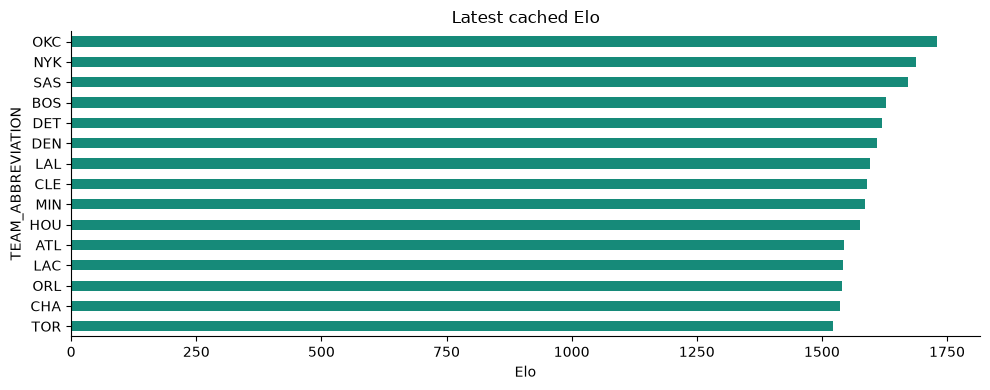

In [4]:
print("Building/loading features and Elo...", flush=True)
team_games, matchup, latest_elos = load_or_build_model_frames(**settings)
print(f"{len(team_games):,} team rows -> {len(matchup.x):,} matchups; {len(matchup.feature_names)} inputs")
team_view = team_games[team_games["TEAM_ABBREVIATION"] == HOME].sort_values("GAME_DATE")
display(team_view[["GAME_DATE", "MATCHUP", "PTS", "WIN", "REST_DAYS", "ROLLING_10_PTS", "ROLLING_10_WIN"]].tail(10))
display(matchup.full[["GAME_DATE", "HOME_TEAM", "AWAY_TEAM", "HOME_WIN", "diff_elo_pre", "diff_rolling_10_pts"]].tail(8))
display(pd.DataFrame([
    {"feature_set": fs, "feature_mode": mode,
     "input_count": len(select_feature_names(matchup.full, feature_set=fs, feature_mode=mode, use_elo=True))}
    for fs in ["deltas", "full"] for mode in ["base", "lean", "full"]]))
display(pd.DataFrame({"Selected inputs": matchup.feature_names}))
leaderboard = latest_elos.sort_values("ELO", ascending=False)
display(leaderboard.head(10))
leaderboard.head(15).sort_values("ELO")["ELO"].plot.barh(color="#168a79", title="Latest cached Elo")
plt.xlabel("Elo")
plt.tight_layout()
plt.savefig(REPORTS / "elo.png", dpi=150)
plt.show()
leaderboard.to_csv(REPORTS / "elo_leaderboard.csv")

## 4. Training and holdout predictions
StandardScaler normalizes inputs and logistic regression learns home-win probabilities. The earliest 80% of rows trains the model; the latest 20% is held out. Three temporal CV folds also test later rows using earlier training data.

Accuracy measures correct winners. Lower log loss and Brier scores mean better probabilities; higher ROC AUC means better ranking. A constant training home-win rate is the baseline. The holdout is row-based and may split a date; the date-based evaluation appears below.

In [5]:
print("Training and running three temporal folds...", flush=True)
result = train_model(**settings, cv_splits=3)
split = int(len(matchup.x) * 0.8)
test = matchup.full.iloc[split:].copy()
probabilities = result.model.predict_proba(matchup.x.iloc[split:])[:, 1]
baseline = np.full(len(test), matchup.y.iloc[:split].mean())
comparison = pd.DataFrame({
    "Model": evaluate_probabilities(matchup.y.iloc[split:], probabilities),
    "Constant home-win baseline": evaluate_probabilities(matchup.y.iloc[split:], baseline)})
display(comparison)
print(f"Train: {split:,}; holdout: {len(test):,}")
print("Holdout dates:", test["GAME_DATE"].min(), "through", test["GAME_DATE"].max())
display(result.cv_scores)
test["home_probability"] = probabilities
test["predicted_winner"] = np.where(probabilities >= 0.5, test["HOME_TEAM"], test["AWAY_TEAM"])
test["actual_winner"] = np.where(test["HOME_WIN"] == 1, test["HOME_TEAM"], test["AWAY_TEAM"])
test["confidence"] = np.maximum(probabilities, 1 - probabilities)
test["correct"] = test["predicted_winner"] == test["actual_winner"]
display(test[["GAME_DATE", "AWAY_TEAM", "HOME_TEAM", "predicted_winner", "confidence", "actual_winner", "correct"]].tail(12))
comparison.to_csv(REPORTS / "evaluation.csv")
test.to_csv(REPORTS / "holdout_predictions.csv", index=False)
result.cv_scores.to_csv(REPORTS / "temporal_cv.csv", index=False)

Training and running three temporal folds...


,Model,Constant home-win baseline
accuracy,0.680824,0.557272
log_loss,0.588818,0.686767
brier_score,0.202107,0.246816
roc_auc,0.749953,0.500000


Train: 3,107; holdout: 777
Holdout dates: 2026-01-06 00:00:00 through 2026-06-13 00:00:00


,accuracy,log_loss,brier_score,roc_auc,fold,train_games,test_games
0,0.659114,0.620304,0.215402,0.714816,1.0,971.0,971.0
1,0.678682,0.636064,0.207901,0.741577,2.0,1942.0,971.0
2,0.668383,0.610795,0.212004,0.721792,3.0,2913.0,971.0


,GAME_DATE,AWAY_TEAM,HOME_TEAM,predicted_winner,confidence,actual_winner,correct
3872,2026-05-22,OKC,SAS,OKC,0.634884,OKC,True
3873,2026-05-23,NYK,CLE,CLE,0.514803,NYK,False
3874,2026-05-24,OKC,SAS,OKC,0.659093,SAS,False
3875,2026-05-25,NYK,CLE,NYK,0.506735,NYK,True
3876,2026-05-26,SAS,OKC,OKC,0.678802,OKC,True
3877,2026-05-28,OKC,SAS,OKC,0.652677,SAS,False
3878,2026-05-30,SAS,OKC,OKC,0.670087,SAS,False
3879,2026-06-03,NYK,SAS,SAS,0.762574,NYK,False
3880,2026-06-05,NYK,SAS,SAS,0.614960,NYK,False
3881,2026-06-08,SAS,NYK,SAS,0.511018,SAS,True


## 5. Calibration and coefficients
A well-calibrated 70% forecast should win about 70% of the time. The diagonal is ideal calibration. Coefficients show associations after standardization, not causal effects; correlated inputs can make individual coefficients difficult to interpret.

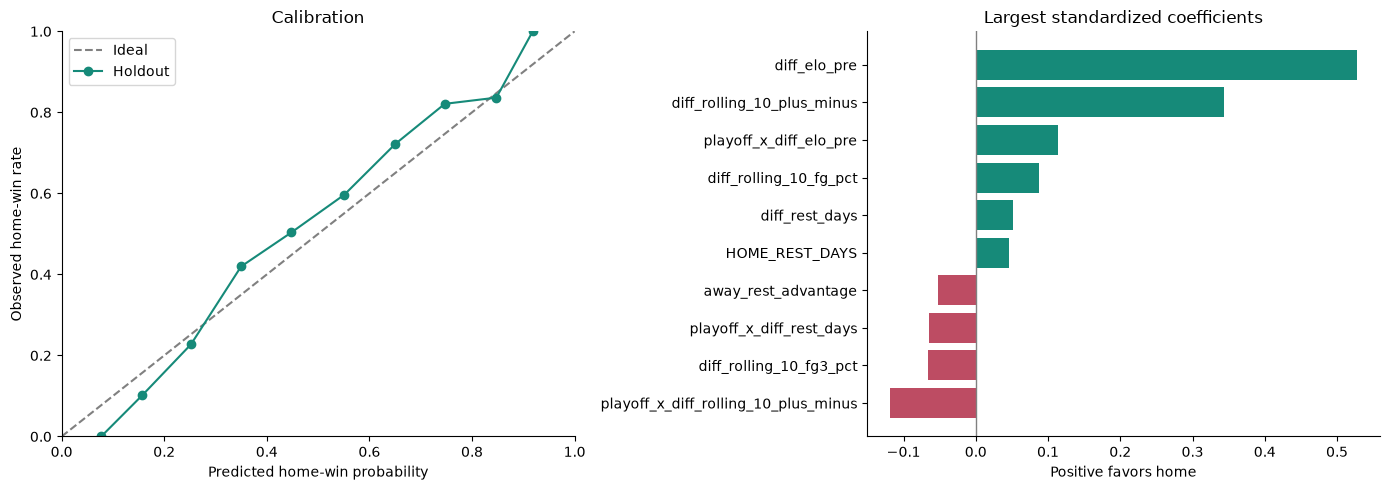

,feature,coefficient,abs_coefficient,odds_ratio_per_1_std,direction
0,diff_elo_pre,0.527189,0.527189,1.694163,home
1,diff_rolling_10_plus_minus,0.344200,0.344200,1.410861,home
2,playoff_x_diff_rolling_10_plus_minus,-0.118245,0.118245,0.888478,away
3,playoff_x_diff_elo_pre,0.113607,0.113607,1.120312,home
4,diff_rolling_10_fg_pct,0.087373,0.087373,1.091303,home
5,diff_rolling_10_fg3_pct,-0.066318,0.066318,0.935833,away
6,playoff_x_diff_rest_days,-0.064672,0.064672,0.937375,away
7,away_rest_advantage,-0.051888,0.051888,0.949435,away
8,diff_rest_days,0.051069,0.051069,1.052395,home
9,HOME_REST_DAYS,0.046012,0.046012,1.047087,home


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cal = result.calibration
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Ideal")
axes[0].plot(cal["predicted_probability_bin"], cal["actual_win_rate"], "o-", color="#168a79", label="Holdout")
axes[0].set(xlabel="Predicted home-win probability", ylabel="Observed home-win rate", title="Calibration", xlim=(0, 1), ylim=(0, 1))
axes[0].legend()
coef = result.feature_importance.head(10).sort_values("coefficient")
axes[1].barh(coef["feature"], coef["coefficient"], color=np.where(coef["coefficient"] >= 0, "#168a79", "#bd4c63"))
axes[1].axvline(0, color="gray", linewidth=1)
axes[1].set(title="Largest standardized coefficients", xlabel="Positive favors home")
fig.tight_layout()
fig.savefig(REPORTS / "calibration_and_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
display(result.feature_importance.head(12))
result.calibration.to_csv(REPORTS / "calibration.csv", index=False)
result.feature_importance.to_csv(REPORTS / "coefficients.csv", index=False)

## 6. Walk-forward evaluation and early-season history
Walk-forward CV uses whole future date blocks. Earlier warmup seasons, rolling carryover, and decaying prior-season summaries are also implemented. This second feature example shows those settings without changing the main model.

In [7]:
walk_forward = walk_forward_cv_scores(result.model, matchup.x, matchup.y, matchup.full["GAME_DATE"], splits=3)
display(walk_forward)
walk_forward.to_csv(REPORTS / "walk_forward_cv.csv", index=False)
history_settings = {
    **settings, "seasons": ["2024-25", "2025-26"], "warmup_seasons": ["2023-24"],
    "rolling_history": "carryover", "use_prior_season_features": True, "prior_decay_games": 30}
history_teams, history_matchup, _ = load_or_build_model_frames(**history_settings)
prior_columns = [c for c in history_teams.columns if "PRIOR" in c]
display(history_teams.loc[history_teams["TEAM_ABBREVIATION"] == HOME,
                         ["GAME_DATE", "SEASON_YEAR", *prior_columns]].tail(8))
print(f"Alternative history: {len(history_matchup.x):,} target-season games; warmup supplies earlier history.")

,accuracy,log_loss,brier_score,roc_auc,fold,train_games,test_games,test_start,test_end
0,0.648026,0.627787,0.218730,0.704596,1.0,1158.0,912.0,2024-04-09,2025-02-11
1,0.680180,0.641971,0.209062,0.737219,2.0,2070.0,888.0,2025-02-12,2025-12-15
2,0.672786,0.607717,0.210576,0.726015,3.0,2958.0,926.0,2025-12-17,2026-06-13


,GAME_DATE,SEASON_YEAR,PRIOR_SEASON_WIN,PRIOR_SEASON_PLUS_MINUS,PRIOR_SEASON_WEIGHT,DECAYED_PRIOR_SEASON_WIN,DECAYED_PRIOR_SEASON_PLUS_MINUS
527,2026-04-12,2025,0.72043,8.688172,0.0,0.0,0.0
528,2026-04-19,2025,0.72043,8.688172,0.0,0.0,0.0
529,2026-04-21,2025,0.72043,8.688172,0.0,0.0,0.0
530,2026-04-24,2025,0.72043,8.688172,0.0,0.0,0.0
531,2026-04-26,2025,0.72043,8.688172,0.0,0.0,0.0
532,2026-04-28,2025,0.72043,8.688172,0.0,0.0,0.0
533,2026-04-30,2025,0.72043,8.688172,0.0,0.0,0.0
534,2026-05-02,2025,0.72043,8.688172,0.0,0.0,0.0


Alternative history: 2,619 target-season games; warmup supplies earlier history.


## 7. Small tuning runs
These compact comparisons exercise rolling-window search, Elo search, and the combined grid. Enlarge lists for bigger experiments, or set RUN_SMALL_TUNING=False above to skip them.

Repeatedly selecting settings using the same holdout reduces its independence. Reserve a separate final period for final model assessment.

In [8]:
tuning_outputs = {}
if RUN_SMALL_TUNING:
    print("Comparing rolling windows 10 and 20...", flush=True)
    tuning_outputs["rolling"] = tune_rolling_settings(
        SEASONS, rolling_windows=[10, 20], min_periods_values=[1],
        season_types=SEASON_TYPES, feature_mode="lean", use_elo=True,
        elo_k=15, elo_playoff_k=15, elo_carryover=0.65, cv_splits=3)
    print("Comparing Elo K 15 and 20...", flush=True)
    tuning_outputs["elo"] = tune_elo_settings(
        SEASONS, rolling_window=10, min_periods=1, elo_k_values=[15, 20],
        elo_home_advantages=[65], elo_carryovers=[0.65], elo_playoff_k=15,
        season_types=SEASON_TYPES, feature_mode="lean", cv_splits=3)
    print("Comparing base and lean feature modes...", flush=True)
    tuning_outputs["grid"] = tune_model_grid(
        SEASONS, feature_sets=["deltas"], feature_modes=["base", "lean"],
        rolling_windows=[10], min_periods_values=[1], elo_k_values=[15],
        elo_playoff_k_values=[15], elo_carryover_values=[0.65],
        season_types=SEASON_TYPES, cv_splits=3, cv_method="walk-forward")
    for name, frame in tuning_outputs.items():
        print(name.title())
        display(frame[["feature_mode", "rolling_window", "elo_k", "accuracy", "log_loss", "cv_mean_log_loss"]].sort_values("cv_mean_log_loss"))
        frame.to_csv(REPORTS / f"tuning_{name}.csv", index=False)
else:
    print("Small tuning disabled.")

Comparing rolling windows 10 and 20...


Comparing Elo K 15 and 20...


Comparing base and lean feature modes...


Rolling


,feature_mode,rolling_window,elo_k,accuracy,log_loss,cv_mean_log_loss
1,lean,20,15,0.694981,0.586534,0.620167
0,lean,10,15,0.680824,0.588818,0.622388


Elo


,feature_mode,rolling_window,elo_k,accuracy,log_loss,cv_mean_log_loss
1,lean,10,20,0.683398,0.589605,0.622105
0,lean,10,15,0.680824,0.588818,0.622388


Grid


,feature_mode,rolling_window,elo_k,accuracy,log_loss,cv_mean_log_loss
0,base,10,15,0.691120,0.583555,0.614839
1,lean,10,15,0.680824,0.588818,0.625825


## 8. Revisit existing experiments
These existing report files record earlier runs, including broader grids and warmup/history experiments. They are not rerun here. Results from different data periods and validation settings are not directly comparable.

In [9]:
saved_experiments = sorted({*(ROOT / "reports").glob("*tuning*.csv"), *(ROOT / "reports").glob("*grid*.csv")})
inventory = []
for path in saved_experiments:
    frame = pd.read_csv(path)
    metric = "cv_mean_log_loss" if "cv_mean_log_loss" in frame else "log_loss"
    inventory.append({"file": path.name, "configurations": len(frame), "ranking_metric": metric,
                      "best_score": frame[metric].min() if metric in frame else np.nan})
display(pd.DataFrame(inventory))
for path in saved_experiments:
    frame = pd.read_csv(path)
    print(path.name)
    metric = "cv_mean_log_loss" if "cv_mean_log_loss" in frame else "log_loss"
    if metric in frame:
        frame = frame.sort_values(metric)
    cols = [c for c in ["feature_set", "feature_mode", "rolling_history", "use_prior_season_features",
                        "rolling_window", "min_periods", "elo_k", "elo_playoff_k", "elo_carryover",
                        "cv_mean_log_loss", "log_loss"] if c in frame]
    display(frame[cols].head(3))

,file,configurations,ranking_metric,best_score
0,elo_tuning_results.csv,75,cv_mean_log_loss,0.620616
1,model_grid_2024_25_2025_26_smoke.csv,2,log_loss,0.548213
2,model_grid_2025_26_cv.csv,432,cv_mean_log_loss,0.627239
3,model_grid_2025_26_full_cv.csv,432,cv_mean_log_loss,0.627239
4,model_grid_2025_26_warmup_small_cv.csv,48,cv_mean_log_loss,0.623747
5,model_grid_smoke.csv,2,log_loss,0.514612
6,tuning_results.csv,9,cv_mean_log_loss,0.621150


elo_tuning_results.csv


,feature_set,rolling_window,min_periods,elo_k,elo_carryover,cv_mean_log_loss,log_loss
15,deltas,20,7,15.0,0.5,0.620616,0.592113
18,deltas,20,7,15.0,0.5,0.620749,0.592148
0,deltas,20,7,10.0,0.5,0.620750,0.592417


model_grid_2024_25_2025_26_smoke.csv


,feature_set,feature_mode,rolling_window,min_periods,elo_k,elo_playoff_k,elo_carryover,log_loss
0,deltas,base,20,7,20.0,30.0,0.75,0.548213
1,deltas,lean,20,7,20.0,30.0,0.75,0.554307


...

,feature_set,feature_mode,rolling_history,use_prior_season_features,rolling_window,min_periods,elo_k,elo_playoff_k,elo_carryover,cv_mean_log_loss,log_loss
0,deltas,lean,same-season,False,10,1,15.0,15.0,0.65,0.623747,0.547187
1,deltas,lean,same-season,True,10,1,15.0,15.0,0.65,0.623747,0.547187
2,deltas,lean,same-season,False,10,1,15.0,25.0,0.65,0.623973,0.547862


model_grid_smoke.csv


,feature_set,feature_mode,rolling_window,min_periods,elo_k,elo_playoff_k,elo_carryover,log_loss
0,deltas,base,20,7,20.0,30.0,0.75,0.514612
1,deltas,lean,20,7,20.0,30.0,0.75,0.521534


tuning_results.csv


,feature_set,rolling_window,min_periods,elo_k,elo_carryover,cv_mean_log_loss,log_loss
1,deltas,15,7,20,0.75,0.621150,0.594154
4,deltas,20,7,20,0.75,0.621239,0.592539
3,deltas,20,5,20,0.75,0.622872,0.590936


## 9. Save/reload and predict a matchup
The model is saved to its own demo file. This confirms reloading preserves predictions and shows both regular-season and playoff contexts. Edit HOME/AWAY above.

The prediction helper assumes three rest days per team and uses saved team features/Elo. It does not simulate future games or roster changes.

In [10]:
model_path = ROOT / "models" / "demo.joblib"
save_training_result(result, model_path)
reloaded = load_training_result(model_path)
rows = []
for playoffs in [False, True]:
    p = predict_matchup(reloaded, home=HOME, away=AWAY, is_playoffs=playoffs)
    assert np.isclose(p, predict_matchup(result, home=HOME, away=AWAY, is_playoffs=playoffs))
    rows.append({"away": AWAY, "home": HOME, "context": "Playoffs" if playoffs else "Regular Season",
                 "home_win_probability": p, "predicted_winner": HOME if p >= 0.5 else AWAY,
                 "confidence": max(p, 1-p)})
display(pd.DataFrame(rows).style.format({"home_win_probability": "{:.1%}", "confidence": "{:.1%}"}))
print("Saved/reloaded:", model_path)
display(reloaded.latest_team_features.loc[[HOME, AWAY], ["GAME_DATE"]])

,away,home,context,home_win_probability,predicted_winner,confidence
0,NYK,BOS,Regular Season,39.4%,NYK,60.6%
1,NYK,BOS,Playoffs,40.6%,NYK,59.4%


Saved/reloaded: C:\Users\ryanv\OneDrive\Desktop\projects\relevant_projects\nba\models\demo.joblib


,GAME_DATE
TEAM_ABBREVIATION,
BOS,2026-05-02
NYK,2026-06-13


## 10. Optional odds comparison
Production can read a CSV with home_team, away_team, home_odds, away_odds. American odds become implied probabilities, normalized across both teams. These example odds are invented, not live quotes. An estimated positive edge alone does not establish profitability.

In [11]:
home_odds, away_odds = -140, 120
raw_home = american_odds_to_implied_probability(home_odds)
raw_away = american_odds_to_implied_probability(away_odds)
market_home = raw_home / (raw_home + raw_away)
model_home = predict_matchup(reloaded, HOME, AWAY)
display(pd.DataFrame([{"example": f"{AWAY} at {HOME}", "home_odds": home_odds, "away_odds": away_odds,
                      "model_home_probability": model_home, "normalized_market_home_probability": market_home,
                      "home_edge": model_home - market_home}]))
print("Set betting_lines_csv in production_config.txt to use your own odds file.")

,example,home_odds,away_odds,model_home_probability,normalized_market_home_probability,home_edge
0,NYK at BOS,-140,120,0.393542,0.562044,-0.168502


Set betting_lines_csv in production_config.txt to use your own odds file.


## 11. Live upcoming predictions
This is the same function as `main.py upcoming`. It prints today's date and the search window, queries every season in that window, and predicts supported games. Preseason/exhibition matchups are excluded. Default: 90 days, adjustable in `production_config.txt`.

The preview shows 30 rows; the CSV holds all predictions. A long-range forecast uses today's saved team snapshot, not simulated intervening games. Production reuses its model by default: set **both retrain=true and refresh=true** to download fresh game logs and rebuild it; return both to false for cached reruns.

If NBA.com is unavailable, this section reports that explicitly and the cached demonstrations remain usable.

In [12]:
from contextlib import redirect_stdout
from io import StringIO
from html import escape
from requests.exceptions import RequestException
live_rows = pd.DataFrame()
if RUN_LIVE:
    print("Contacting NBA.com for the production schedule...", flush=True)
    log = StringIO()
    try:
        with redirect_stdout(log):
            live_rows = run_production_predictions()
    except (RequestException, ValueError, KeyError) as exc:
        print(log.getvalue())
        print(f"Live predictions unavailable: {type(exc).__name__}: {exc}")
    else:
        display(HTML("<details><summary>Full production terminal output</summary><pre>" + escape(log.getvalue()) + "</pre></details>"))
        print(log.getvalue().splitlines()[0])
        if live_rows.empty:
            print("No eligible games returned in the configured window.")
        else:
            print(f"{len(live_rows)} predictions; showing the first 30.")
            columns = ["date", "away", "home", "predicted_winner", "confidence", "home_win_probability"]
            display(live_rows[columns].head(30).style.format({"confidence": "{:.1%}", "home_win_probability": "{:.1%}"}))
            live_rows.to_csv(REPORTS / "upcoming_predictions.csv", index=False)
else:
    print("Live lookup disabled by RUN_LIVE.")

Contacting NBA.com for the production schedule...


Searching for games 90 days ahead of September 9, 2026 (through December 8, 2026).
325 predictions; showing the first 30.


,date,away,home,predicted_winner,confidence,home_win_probability
0,2026-10-20,BOS,DET,DET,50.2%,50.2%
1,2026-10-20,OKC,SAS,OKC,58.5%,41.5%
2,2026-10-20,PHI,NYK,NYK,81.9%,81.9%
3,2026-10-21,ATL,ORL,ORL,55.5%,55.5%
4,2026-10-21,CHA,BKN,CHA,85.0%,15.0%
5,2026-10-21,CHI,TOR,TOR,76.2%,76.2%
6,2026-10-21,DAL,HOU,HOU,81.3%,81.3%
7,2026-10-21,GSW,LAL,LAL,68.6%,68.6%
8,2026-10-21,IND,NOP,IND,52.0%,48.0%
9,2026-10-21,MIL,WAS,MIL,65.9%,34.1%


## 12. Data exports and next runs
The project also exports raw logs, rolling features, and full/delta matchup tables through `inspection.py`. This cell runs that workflow and inventories the tour's outputs.

Terminal commands from the project root:
```powershell
.\.venv\Scripts\python.exe src/main.py upcoming
.\.venv\Scripts\python.exe src/main.py sample --season 2025-26 --season-type Playoffs --limit 10
.\.venv\Scripts\python.exe src/main.py --help
```
The sample command can include games used for training; use holdout/walk-forward for evaluation. Without a venv on this PC, replace the interpreter with `& "$env:LOCALAPPDATA\Programs\Python\Python312\python.exe"`.

Restart the kernel after changing imported Python modules, then Run All.

In [13]:
from inspection import export_model_stages
from inspect import signature
export_settings = {key: value for key, value in settings.items() if key in signature(export_model_stages).parameters}
paths = export_model_stages(**export_settings, output_dir=REPORTS / "data")
display(pd.DataFrame([{"stage": name, "file": str(path.relative_to(ROOT))} for name, path in paths.items()]))
display(pd.DataFrame([{"file": str(p.relative_to(REPORTS)), "KB": round(p.stat().st_size / 1024, 1)}
                      for p in sorted(REPORTS.rglob("*")) if p.is_file()]))
print(f"Tour complete in {perf_counter() - started:.1f}s.")
print("Outputs:", REPORTS)

,stage,file
0,raw_game_logs,reports\demo\data\01_raw_game_logs.csv
1,team_rolling_features,reports\demo\data\02_team_rolling_features.csv
2,matchups_deltas_only,reports\demo\data\03_matchups_deltas_only.csv
3,matchups_full_home_away_diff,reports\demo\data\04_matchups_full_home_away_d...
4,training_features,reports\demo\data\05_training_features.csv


,file,KB
0,calibration.csv,0.4
1,calibration_and_coefficients.png,103.2
2,coefficients.csv,1.4
3,data\01_raw_game_logs.csv,1203.3
4,data\02_team_rolling_features.csv,2029.1
5,data\03_matchups_deltas_only.csv,727.4
6,data\04_matchups_full_home_away_diff.csv,2746.5
7,data\05_training_features.csv,727.4
8,elo.png,33.3
9,elo_leaderboard.csv,2.0


Tour complete in 58.4s.
Outputs: C:\Users\ryanv\OneDrive\Desktop\projects\relevant_projects\nba\reports\demo
